# Convolutional Neural Networks & Residual Networks in PyTorch

In [1]:
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

# Set random seed for reproducibility
torch.manual_seed(302)
np.random.seed(302)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [2]:
# Define transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

BATCH_SIZE = 64

# Download and load CIFAR-10 training dataset
trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

# Download and load CIFAR-10 test dataset
testset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Classes in CIFAR-10
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100.0%


torch.Size([64, 3, 32, 32])
torch.Size([64])


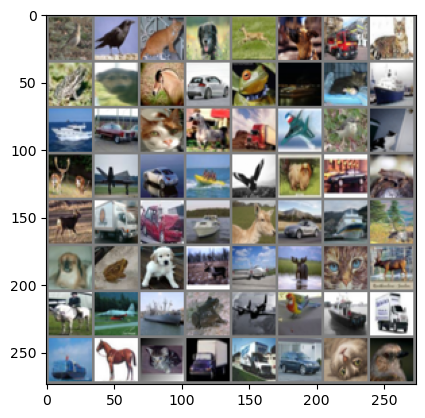

bird  bird  cat   dog   deer  dog   truck cat   frog  dog   horse car   frog  ship  cat   ship  ship  car   cat   horse truck plane bird  cat   deer  plane car   ship  bird  dog   car   frog  deer  truck car   ship  deer  car   ship  deer  dog   frog  dog   deer  plane deer  cat   deer  horse plane ship  frog  plane bird  ship  truck ship  horse cat   truck truck car   cat   bird 


In [3]:
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

print(images.shape)
print(labels.shape)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(BATCH_SIZE)))

## Create a simple Convolutional Neural Network (CNN)

In [4]:
class ConvNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=(3, 3))
        self.pool = nn.MaxPool2d(kernel_size=(2, 2), stride=2)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=(3, 3))
        self.fc1 = nn.Linear(in_features=16 * 6 * 6, out_features=120)
        self.fc2 = nn.Linear(in_features=120, out_features=84)
        self.fc3 = nn.Linear(in_features=84, out_features=10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


cnn = ConvNet()

out = cnn(images)
out.shape

torch.Size([64, 10])

Animation of `nn.Conv2d(in_channels=8, out_channels=8, kernel_size=(3, 3))`

![conv](https://animatedai.github.io/media/convolution-animation-3x3-kernel.gif)

In [5]:
class DebugConvNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=(3, 3))
        self.pool = nn.MaxPool2d(kernel_size=(2, 2), stride=2)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=(3, 3))
        self.fc1 = nn.Linear(in_features=16 * 6 * 6, out_features=120)
        self.fc2 = nn.Linear(in_features=120, out_features=84)
        self.fc3 = nn.Linear(in_features=84, out_features=10)

    def forward(self, x):
        print(f'Input shape: {x.shape}\n')
        x = self.conv1(x)
        print(f'After conv1: {x.shape}')
        x = F.relu(x)
        print(f'After relu: {x.shape}')
        x = self.pool(x)
        print(f'After pool: {x.shape}')

        x = self.conv2(x)
        print(f'After conv2: {x.shape}')
        x = F.relu(x)
        print(f'After relu: {x.shape}')
        x = self.pool(x)
        print(f'After pool: {x.shape}')

        x = torch.flatten(x, 1) # flatten all dimensions except batch
        print(f'After flatten: {x.shape}')
        x = F.relu(self.fc1(x))
        print(f'After fc1: {x.shape}')
        x = F.relu(self.fc2(x))
        print(f'After fc2: {x.shape}')
        x = self.fc3(x)
        print(f'After fc3: {x.shape}')
        return x


debug_cnn = DebugConvNet()
out = debug_cnn(images)

Input shape: torch.Size([64, 3, 32, 32])

After conv1: torch.Size([64, 6, 30, 30])
After relu: torch.Size([64, 6, 30, 30])
After pool: torch.Size([64, 6, 15, 15])
After conv2: torch.Size([64, 16, 13, 13])
After relu: torch.Size([64, 16, 13, 13])
After pool: torch.Size([64, 16, 6, 6])
After flatten: torch.Size([64, 576])
After fc1: torch.Size([64, 120])
After fc2: torch.Size([64, 84])
After fc3: torch.Size([64, 10])


### Question: `conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=(3, 3))`.
### How many parameters does `conv1` have?


Since `kernel_size=(3, 3)` and `in_channels=3`, each filter has $3\times3\times3$ weights and a single bias term (since `bias=True` by default).

Since we have `out_channels=6` filters, the total number of parameters is $6\times(3\times3\times3+1)=168$.


In [6]:
for name, param in cnn.conv1.named_parameters():
    print(f'{name}: {np.prod(param.shape)}')

weight: 162
bias: 6


### Question: `conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=(3, 3))`.
### How many parameters does `conv2` have?

Since `kernel_size=(3, 3)` and `in_channels=6`, each filter has $3\times3\times6$ weights and a single bias term.

Since we have `out_channels=16` filters, the total number of parameters is $16\times(3\times3\times6+1)=880$.

In [7]:
for name, param in cnn.conv2.named_parameters():
    print(f'{name}: {np.prod(param.shape)}')

weight: 864
bias: 16


### Question: `fc3 = nn.Linear(in_features=84, out_features=10)`.
### How many parameters does `fc3` have?


Since `in_features=84` and `out_features=10`, `fc3` has $84\times10$ weights and $10$ bias terms.

Thus, the total number of parameters is $84\times10+10=850$.

In [8]:
for name, param in cnn.fc3.named_parameters():
    print(f'{name}: {np.prod(param.shape)}')

weight: 840
bias: 10


## Let's train the model


In [9]:
def train_model(model, trainloader, criterion, optimizer, num_epochs):
    model.train()
    for epoch in range(num_epochs):  # loop over the dataset NUM_EPOCHS times
        running_loss = 0.0
        for i, data in enumerate(trainloader):
            # get the images and labels and move to device
            images, labels = data
            images, labels = images.to(device), labels.to(device)

            # zero the parameter gradients
            optimizer.zero_grad()

            # forward + backward + optimize
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # print statistics
            running_loss += loss.item()
            if i % 200 == 199:    # print every 200 mini-batches
                print(f'Epoch {epoch + 1} | Mini-Batch #{i + 1:5d} | Training Loss: {running_loss / 200:.3f}')
                running_loss = 0.0

In [10]:
from pathlib import Path

TRAIN_MODEL = True

cnn = ConvNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=0.001)

# setup checkpoint path
CHECKPOINT_PATH = Path('./checkpoints/cnn.pth')
CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)

if TRAIN_MODEL:
    train_model(cnn, trainloader, criterion, optimizer, num_epochs=10)
    torch.save(cnn.state_dict(), CHECKPOINT_PATH) # save the model after training
else:
    cnn.load_state_dict(torch.load(CHECKPOINT_PATH)) # load the model from disk

Epoch 1 | Mini-Batch #  200 | Training Loss: 1.920
Epoch 1 | Mini-Batch #  400 | Training Loss: 1.622
Epoch 1 | Mini-Batch #  600 | Training Loss: 1.528
Epoch 2 | Mini-Batch #  200 | Training Loss: 1.395
Epoch 2 | Mini-Batch #  400 | Training Loss: 1.352
Epoch 2 | Mini-Batch #  600 | Training Loss: 1.335
Epoch 3 | Mini-Batch #  200 | Training Loss: 1.263
Epoch 3 | Mini-Batch #  400 | Training Loss: 1.238
Epoch 3 | Mini-Batch #  600 | Training Loss: 1.220
Epoch 4 | Mini-Batch #  200 | Training Loss: 1.151
Epoch 4 | Mini-Batch #  400 | Training Loss: 1.132
Epoch 4 | Mini-Batch #  600 | Training Loss: 1.140
Epoch 5 | Mini-Batch #  200 | Training Loss: 1.066
Epoch 5 | Mini-Batch #  400 | Training Loss: 1.083
Epoch 5 | Mini-Batch #  600 | Training Loss: 1.073
Epoch 6 | Mini-Batch #  200 | Training Loss: 1.005
Epoch 6 | Mini-Batch #  400 | Training Loss: 1.014
Epoch 6 | Mini-Batch #  600 | Training Loss: 1.019
Epoch 7 | Mini-Batch #  200 | Training Loss: 0.976
Epoch 7 | Mini-Batch #  400 | T

## Test on some test images

In [11]:
def eval_classifier(model, testloader):
    model.eval()

    correct = 0
    total = 0
    all_predicted = []
    all_labels = []

    # since we're not training, we don't need to calculate the gradients for our outputs
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            # move to device
            images, labels = images.to(device), labels.to(device)

            # calculate outputs by running images through the network
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            _, predicted = torch.max(probs, dim=1)
            total += labels.shape[0]
            correct += (predicted == labels).sum().item()

            # Store predictions and labels for confusion matrix
            all_predicted.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')


In [13]:
eval_classifier(resnet, testloader)

NameError: name 'resnet' is not defined

# Residual Connections

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding='same')
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding='same')

        # Add projection shortcut if dimensions don't match
        self.shortcut = nn.Identity()  # do nothing if dimensions match
        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1)  # 1x1 convolution

    def forward(self, x):
        F_x = self.conv2(self.relu(self.conv1(x)))
        # Note: F_x has the same height and width as x (padding='same')
        # If the number of channels doesn't match, we use a 1x1 convolution on x to match the dimensions
        x = self.shortcut(x)
        return self.relu(F_x + x)

In [ ]:
dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

res = ResidualBlock(in_channels=3, out_channels=6).to(device)
out = res(images)
out.shape

In [ ]:
class ResidualBlockWithBatchNorm(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, stride=stride, bias=False)  # No bias
        self.bn1 = nn.BatchNorm2d(out_channels)  # BatchNorm includes bias
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)  # No bias
        self.bn2 = nn.BatchNorm2d(out_channels)  # BatchNorm includes bias

        # Projection shortcut if needed
        self.shortcut = nn.Identity()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += self.shortcut(x)
        out = self.relu(out)

        return out

In [ ]:
res = ResidualBlockWithBatchNorm(in_channels=3, out_channels=6, stride=2).to(device)
out = res(images)
out.shape

In [ ]:
class SmallResNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # Initial convolution layer
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding='same')
        self.bn1 = nn.BatchNorm2d(16)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Residual blocks
        self.layer1 = ResidualBlockWithBatchNorm(in_channels=16, out_channels=32, stride=1)
        self.layer2 = ResidualBlockWithBatchNorm(in_channels=32, out_channels=64, stride=2)
        self.layer3 = ResidualBlockWithBatchNorm(in_channels=64, out_channels=128, stride=2)

        # Average all values within a channel
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        # Initial conv block
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # Residual blocks
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        # Classification head
        x = self.avgpool(x)
        x = torch.flatten(x, 1)  # Flatten all dimensions except batch
        x = self.fc(x)

        return x

# Create model instance and test with sample data
model = SmallResNet().to(device)
output = model(images)
print(f"Input shape: {images.shape}")
print(f"Output shape: {output.shape}")

In [ ]:
resnet = SmallResNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.parameters(), lr=0.001)

# setup checkpoint path
CHECKPOINT_PATH = Path('./checkpoints/resnet.pth')
CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)

if TRAIN_MODEL:
    train_model(resnet, trainloader, criterion, optimizer, num_epochs=10)
    torch.save(resnet.state_dict(), CHECKPOINT_PATH) # save the model after training
else:
    resnet.load_state_dict(torch.load(CHECKPOINT_PATH)) # load the model from disk

In [ ]:
eval_classifier(resnet, testloader)